# System's description

We want to simulate is composed of $M$ deteriorating components over a time horizon $H$. Each time $t \in [T]$ corresponds to a maintenance slot. We suppose that the $T$ maintenance slots are periodically scheduled with interval time $h$, i.e., $t \times h$ is the time of maintenance slot $t$. Several cracks are present in each component of the system. The deterioration of the component corresponds to the propagation of the cracks. 
Between two maintenance slots $t$ and $t+1$, we have access to noisy measurements $X_i^m \in \mathbb{R}^{d^m}$ of the crack depth evolution at each time $i \in \left[th,(t+1)h\right]$ for each component $m \in [M]$. We assume that the crack depth in each component evolves independently.

## Crack depth evolution in a component

We describe how to model the crack depth evolution in a component between two maintenance slots and a numerical method to simulate it. For convenience, we omit the index $m$.

### Fatigue Crack Growth (FCG) 

Fatigue Crack Growth (FCG) models the appearance and propagation of a crack within a bearing. Each coordinate $k \in [d]$ of the crack depth $y^k$ evolves according to the following Paris-Erdogan differential equation 
\begin{equation}\label{eq:Paris_erdogan}
	\frac{dy^k}{dt} = C (\beta e^{\gamma} \sqrt{y^k})^n
\end{equation}
where $C$ and $n$ are parameters depending on the material property, $\beta$ is the base stress level of the component and $\gamma$ determines the extra stress level of the component. This latter parameter depends on the environment state. The greater $\gamma$ is, the faster the crack propagates.


### Simulation

We simulate the cracks in a component with FCG where the extra stress level is a random variable. Let $\Gamma_i$ be such random variable at time $i$. The system's extra stress level transits randomly from $\Gamma_i = \gamma$ to $\Gamma_{i+1} = \gamma'$ with probability $p_{\Gamma}(\gamma'|\gamma)$ for all $\gamma, \gamma' \in \mathcal{X}_{\Gamma}$. We assume that the crack propagation rate stagnates or increases:$$
\begin{align}\label{eq:gamma_transition}
	p_{\Gamma}(\gamma'|\gamma) = 0 \ \text{if} \ \gamma' < \gamma
\end{align}$$
We combine this model with the following discretization scheme from the literature of Paris-Erdogan equation. Let $\gamma_{i}$ and $(y^k_{i})_{1 \leq k \leq d}$ be respectively the extra stress level and the crack length at time $i$  :$$
\begin{align}\label{eq:discretization}\tag{1}
	&\Gamma_{i+1} \sim p_{\Gamma}(. | \gamma_{i})\\
	&y^k_{i+1} = y^k_{i} + e^{W_{i+1}}C \left(\beta e^{\Gamma_{i+1}} \sqrt{y^k_{i}} \right)^n \Delta t
\end{align}
$$
where $W_i \sim \mathcal{N} (0, \Sigma_w)$, $\Sigma_w \in \mathbb{R}^{d \times d}$, and $\Delta t$ represents the discretization time step of the scheme. Note that the stochasticity of the scheme $\eqref{eq:discretization}$ comes from $W_i$ and $\Gamma_i$. We assume that the component fails when the crack length reaches a critical threshold $y_{\mathrm{c}}$. Hence, a failure happens at $i$ when there is at least one coordinate $k \in [d]$ such that $Y^k_i \geq y_{\mathrm{c}}$. 

Since we have noisy measurements $X_i$ of the crack depth $Y_i$, we add a white noise:
\begin{equation}\label{eq:measurements_error}
	X_i = Y_i + \xi
\end{equation}
where $\xi \sim \mathcal{N}(0, \Sigma_{\xi})$ with $\Sigma_{\xi} \in \mathbb{R}^{d \times d}$ is a measurement error.

### Parameter Settings

Given a number of component $M$ and the interval time between two maintenance slots $h$, to evaluate a policy we need to set the parameters of the simulator. 

First we set the replacement costs $C_R^m$ and the failure costs $C_F^m$ such that $C_F^m = 100$ and $C_R^m = 10$ for each component $m \in [M]$. 

Second, we set the parameters of Scheme $(1)$: $y_{\mathrm{c}}$, $\Delta t$, $C$, $n$, $\beta$, $\Sigma_w$, $\Sigma_{\xi}$, the transition probabilities $p_{\Gamma}$ and the space $\mathcal{X}_{\Gamma}$. For each component, we choose the same critical threshold $y_{\mathrm{c}} = 100cm$ and same discretization time step $\Delta t=1$ as in [Le et al. 2014]. 

Since each component $m \in [M]$ evolves independently, we set a combination of parameters $C^m$, $n^m$, $\beta^m$, $\Sigma^m_w$, $\Sigma^m_{\xi}$, $\mathcal{X}^m_{\Gamma}$ and $p^m_{\Gamma}$. We randomly draw scalar parameters in their respective range $C^m \in [0.001, 0.1]$, $n^m \in [1,2]$, $\beta^m \in [0.5, 1.5]$. 

Then, we set the parameters of probability distributions. Like [Le et al., 2014], we randomly draw a covariance matrix $\Sigma^m_w$ such that $\vert\vert\vert \Sigma^m_w \vert\vert\vert  = 1.7$. As mentioned above the data are in practice very noisy, hence we set a large Frobenius norm value for $\Sigma^m_{\xi}$. We randomly draw a covariance matrix $\Sigma^m_{\xi}$ such that $\vert\vert\vert \Sigma^m_{\xi} \vert\vert\vert = 100$.  
Finally, we randomly draw the size of the finite space $\vert \mathcal{X}^m_{\Gamma} \vert$ in $\{5,\ldots, 15 \}$ and the transition probabilities $p^m_{\Gamma}$ defined as explained in the cell above. Then we split interval $[0,1.2]$ into $\vert \mathcal{X}^m_{\Gamma}\vert - 1$ intervals and we set $\mathcal{X}^m_{\Gamma} = \left\{\frac{1.2k}{\vert \mathcal{X}^m_{\Gamma} \vert-1}, \ k=0,\ldots,\vert \mathcal{X}^m_{\Gamma} \vert -1 \right\}$.

# Imports

In [1]:
using PyCall
using Conda
using Random
using LinearAlgebra
using Distributions

### Number of component 

In [2]:
M = 3

3

### Drawing the parameters

In [3]:
#Random.seed!(123)

#Dimensions
dimensions = zeros(M) 

#number of propagation states of $\Gamma$
nb_propagation_rates = zeros(M)

#Values of Gamma
gamma_es = []

#Transition probability distribution of Gamma
transmats = []

#Parameters of the Paris-Erdogan Equation
Cs =zeros(M)
ns = zeros(M)
beta_bs = zeros(M)

sigma_ws = []
sigma_xhis = []

for m in 1:M
    #Define the dimension
    dimensions[m] = 3
    
    
    #Define number of propagation states
    nb_propagation_rates[m] = Int.(rand(10:20))
    
    #Define the maximal value of gamma
    gamma_e_max = 1.2
    
    #Define the set of possible values for Gamma
    if nb_propagation_rates[m] > 1
        push!(gamma_es,0:(gamma_e_max/(nb_propagation_rates[m]-1)):gamma_e_max)
    else 
        push!(gamma_es,[0])
    end
    
    #Define the transition matrix
    transmat = zeros(Int.(nb_propagation_rates[m]),Int.(nb_propagation_rates[m]))
    #println(nb_propagation_rates[m])
    
    #Define the transition in order to not propapgate too quickly for the parameters
    #We define first randomly the transition matrix elements
    for state_1 in 1:Int.(nb_propagation_rates[m])
        for state_2 in state_1:Int.(nb_propagation_rates[m])
            if state_1 == state_2
                transmat[state_1,state_2] = 10*rand()
            else
                transmat[state_1,state_2] = exp(-state_2+rand())
            end
        end
    end
    transmat = transmat./sum(transmat,dims=2)
    push!(transmats, transmat)
    
    #Define covariance matrice sigma w
    #1.7
    sigma_w = rand(Int.(dimensions[m]),Int.(dimensions[m]))
    sigma_w = transpose(sigma_w)*sigma_w
    eig_val_w = maximum(eigvals(sigma_w))
    sigma_w = (1.7/eig_val_w)*sigma_w
    push!(sigma_ws,sigma_w)
    
    #Define covariance matrice sigma xhi
    #10.0
    sigma_xhi = rand(Int.(dimensions[m]),Int.(dimensions[m]))
    sigma_xhi = transpose(sigma_xhi)*sigma_xhi
    sigma_xhi = (150.0/maximum(eigvals(sigma_xhi)))*sigma_xhi
    push!(sigma_xhis,sigma_xhi)
    
    #draw uniformly a number between 0 and 1
    u = rand()
    Cs[m] = (0.01 - 0.001)*u + 0.001
    
    #draw uniformly a number between 0 and 1
    u = rand()
    ns[m] = (2.0 - 1.0)*u + 1.0
    
    #draw uniformly a number between 0 and 1
    u = rand()
    beta_bs[m] = (1.5 - 0.5)*u + 0.5
end

delta_t=1.0

#Critical value 
d=100

100

## Simulate a trajectory until a failure

In [4]:
function get_sample_data_to_display(sample_size,dimension,nb_propagation_rates,gamma_e,transmat,delta_t,n,sigma_w,C,beta_b,sigma_xhi)
    
    T = sample_size*delta_t
    #range_time = 1:delta_t:sample_size
    
    #Degradation level
    states = ones(sample_size)

    #Observations
    x = zeros(sample_size,dimension)

    #Measurement
    y = zeros(sample_size,dimension)
    #pritnln(MvNormal(zeros(dimension),sigma_xhi))
    
    states[1] = 1
    x[1,:] = rand(dimension)
    y[1,:] = x[1,:] + rand(MvNormal(zeros(dimension),sigma_xhi),1)
    
    t_stop = 1
    
    for t in 2:sample_size
        #println(t)
        
        #Draw a new state from the conditional transition probability
        values = 1:nb_propagation_rates
        probabilities = transmat[Int.(states[t-1]),:]
        d = Categorical(probabilities)
        states[t] = rand(d)
       
        #Draw the factor w in the differential equation
        w = rand(MvNormal(zeros(dimension), sigma_w))
        
        #Next measurement from the differential equation
        x[t,:] = x[t-1,:] + C*map(exp,w).*(beta_b*exp(gamma_e[Int.(states[t])])*map(sqrt,x[t-1,:])).^n*delta_t
        #println(x[t,:])
        
        #Add a white noise for the observations
        y[t,:] = x[t,:] + rand(MvNormal(zeros(dimension),sigma_xhi),1)
        #println(y[t,:])
     
        #println([a >= 100 for a in x[t,:]])
        #We stop the simulation when the 
        if sum([a >= 100 for a in x[t,:]]) >= 1
            t_stop = t
            break
        end
    end
    return gamma_e[Int.(states[1:t_stop])], x[1:t_stop,:], y[1:t_stop,:], t_stop
end

function get_samples_to_display(nb_samples,sample_size,dimension,nb_propagation_rates,gamma_e,transmat,delta_t,n,sigma_w,C,beta_b,sigma_xhi)
    y = []
    lengths = []
    crack_rates = []
    for sample in 1:nb_samples
        crack_rate, x, data, len = get_sample_data(sample_size,dimension,nb_propagation_rates,gamma_e,transmat,delta_t,n,sigma_w,C,beta_b,sigma_xhi)
        push!(crack_rates, crack_rate)
        push!(y, data)
        push!(lengths, len)
    end
    return crack_rates,y,lengths
end

get_samples_to_display (generic function with 1 method)

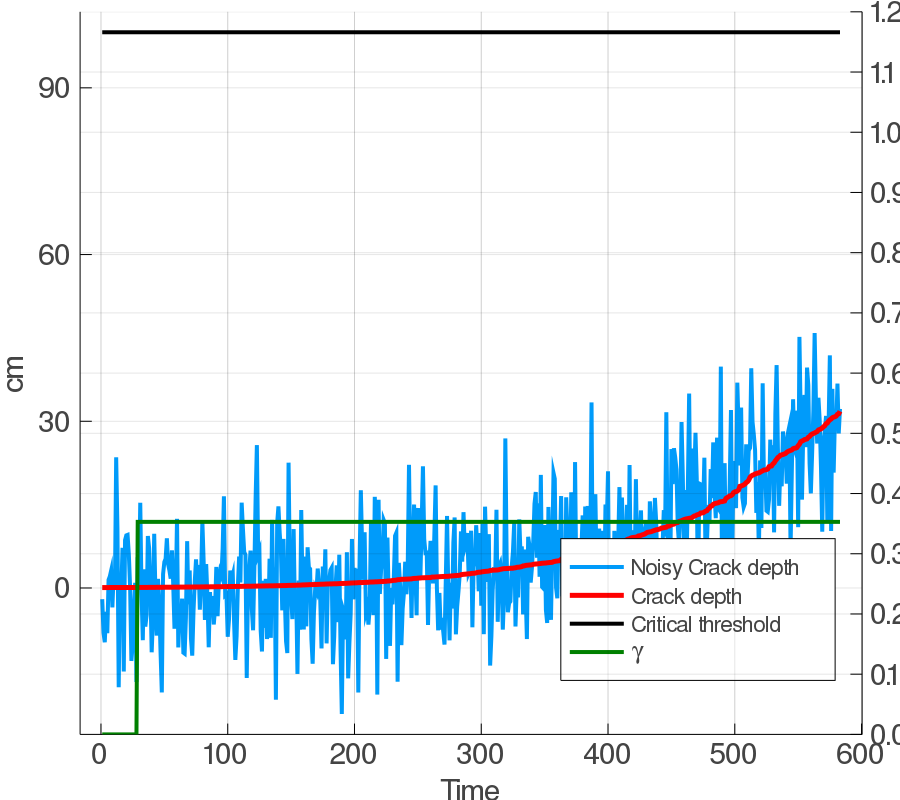

Component :1

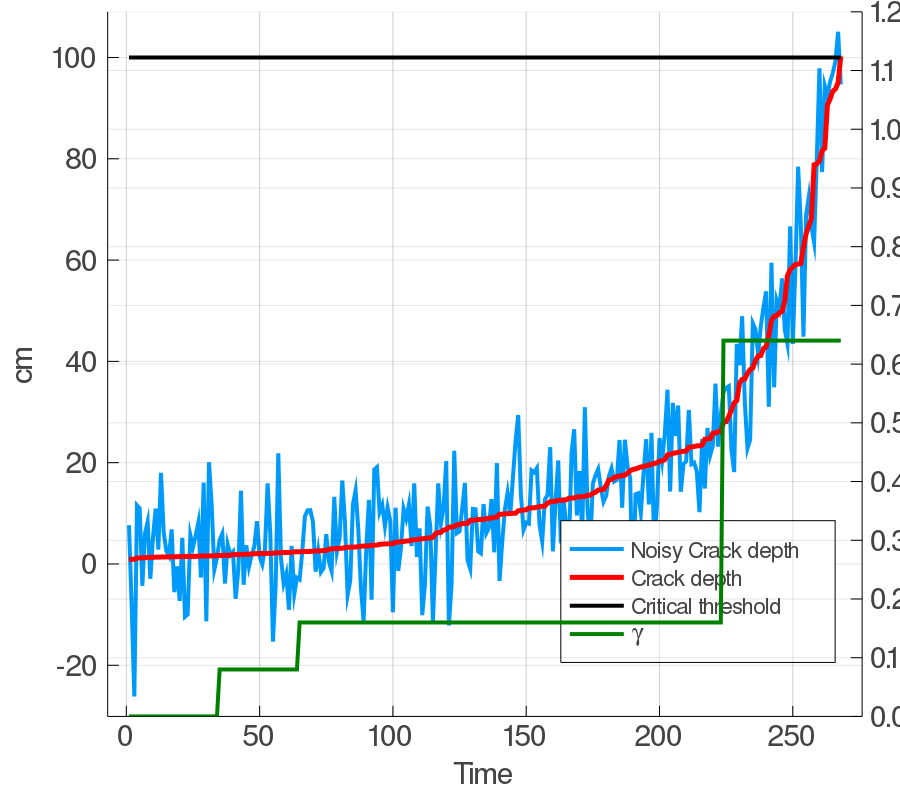


Component :

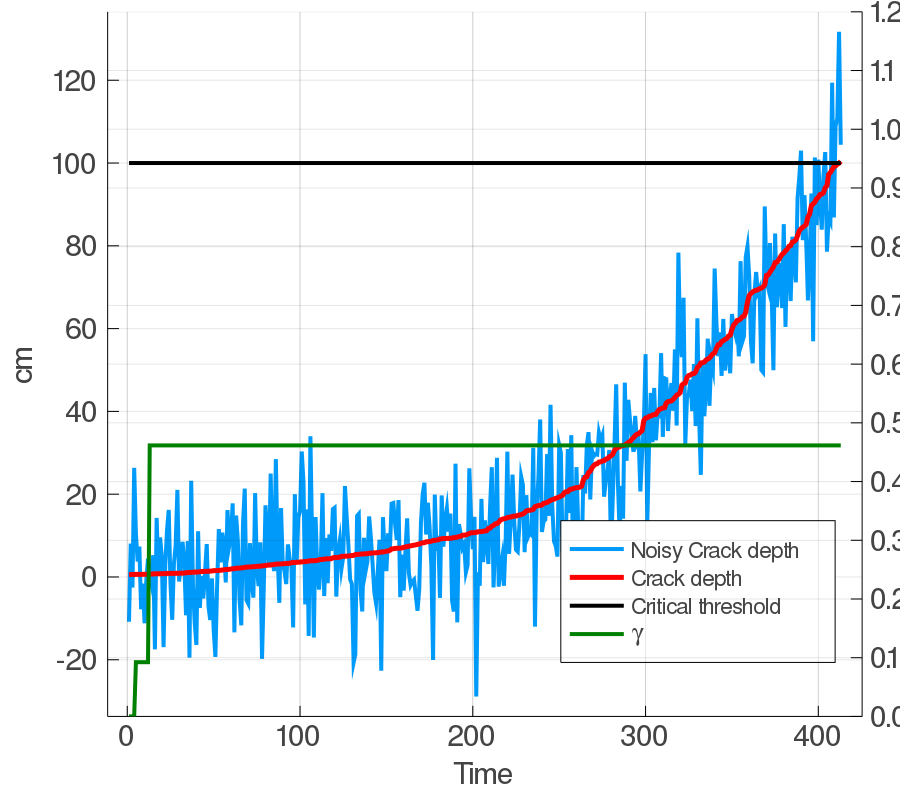

2
Component :3


In [6]:
using Random
using Plots

#pyplot()
using LaTeXStrings
#plot(range_time,x,lw=5,size = (2000, 2000))
sample_size=10000

#%matplotlib notebook
#et_sample_data(sample_size,dimension,nb_propagation_rates,gamma_e,transmat,delta_t,n,sigma_w,C,beta_b,sigma_xhi)
for m in 1:M
    println("Component :", m)
    gamma,x,y,l = get_sample_data_to_display(sample_size,Int.(dimensions[m]),Int.(nb_propagation_rates[m]),gamma_es[m],transmats[m],
                        delta_t,ns[m],sigma_ws[m],Cs[m],beta_bs[m],sigma_xhis[m])
    #println(gamma)
    #Wet Show the first dimension of each component
    #for dim in 1:Int.(dimensions[m])
    dim = 1
    fig = plot(y[:,dim],lw=4,size =(900,800),xlabel = "Time",ylabel="cm",xtickfont=font(20), 
                ytickfont=font(20),
                guidefont=font(20), 
                legendfont=font(15), label="Noisy Crack depth",legend = :bottomright,fmt=:png)
    hline = 100*ones(l)
    #plot(vline([1,2,3])
    plot!(fig,x[:,dim],lw=5, label="Crack depth", linecolor= :red)
    plot!(fig,hline,lw=4, label="Critical threshold",linecolor= :black)
    plot!(fig, NaN.*(1:l),lw=4, label = "\\gamma",linecolor= :green) 
    plot!(twinx(),gamma,lw=4,legend=false,xaxis=false,yticks=0:0.1:1.2,ylims=(0,1.2),ytickfont=font(20),linecolor=:green)
    display(fig)
        #png(string("Crack_depth/Crack_depth_",m,"_",dim))
end